# Phase 3 — Non-Linear Manifold Learning (t-SNE & UMAP)

**Context.** Phase 2 showed that PCA on subject-normalised data (`X_subjz`) reveals weak but statistically detectable phase separation along three interpretable biosignal axes (EDA, HR, temperature). However, PCA is constrained to *linear* projections — it can only find structure that lives on flat planes through the 51-dimensional feature space.

**Why non-linear methods?** If the physiological states (rest → puzzle → recovery) trace out a *curved* manifold rather than a flat subspace, PCA will miss it. t-SNE and UMAP are designed to preserve local neighbourhood structure — they ask "which points are close to which?" rather than "what direction has the most variance?" — and can reveal clusters and trajectories that linear projections flatten out.

**What this notebook does:**
1. Runs t-SNE across multiple perplexity values to test sensitivity
2. Runs UMAP across multiple `n_neighbors` / `min_dist` settings
3. Compares all embeddings (PCA vs. t-SNE vs. UMAP) side-by-side
4. Colors every plot by *both* phase and subject to diagnose whether any visible clusters reflect experimental condition or individual identity
5. Persists all embeddings for Phase 4 evaluation

**Key input:** `X_subjz` (312 × 51), the per-subject z-scored biosignal matrix from Phase 1. We use this — not raw `X` — so the comparison with Phase 2's PCA is apples-to-apples, and because Phase 1 established that subject baselines dominate unless normalised out.

## 0. Environment setup and data ingestion

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(context='notebook', style='whitegrid')
RNG_SEED = 42

# --- Paths (relative to this notebook) ---
BUNDLE_PATH = Path('artifacts/case2_phase1/case2_phase1_bundle.pkl')
ART_DIR = Path('artifacts/case2_phase3')
FIG_DIR = Path('figures/case2_phase3')
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Load Phase 1 bundle ---
bundle = joblib.load(BUNDLE_PATH)

X_subjz  = bundle['X_subjz'].values if hasattr(bundle['X_subjz'], 'values') else bundle['X_subjz']
y_phase  = bundle['y_phase']
subjects = bundle['subject']
features = bundle['feature_cols']

# Ensure consistent types
phase_labels = np.array(y_phase)  # string labels: 'phase1', 'phase2', 'phase3'
subject_ids  = np.array(subjects)

n_samples, n_features = X_subjz.shape
n_subjects = len(np.unique(subject_ids))
print(f'Loaded X_subjz: {n_samples} samples × {n_features} features')
print(f'Subjects: {n_subjects}, Phases: {np.unique(phase_labels)}')

/Users/elena.schneider/cda-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded X_subjz: 312 samples × 51 features
Subjects: 26, Phases: ['phase1' 'phase2' 'phase3']


## 0.1 Retrieve PCA embeddings from Phase 2

We need the PCA 2D projection from Phase 2 so we can place it alongside t-SNE and UMAP in the comparison grid. Rather than depending on a separate saved file, we recompute it here from the same `X_subjz` — this guarantees alignment and lets this notebook run standalone.

In [2]:
pca = PCA(n_components=2, random_state=RNG_SEED)
X_pca_2d = pca.fit_transform(X_subjz)
pca_var = pca.explained_variance_ratio_
print(f'PCA 2D: PC1 = {pca_var[0]:.1%}, PC2 = {pca_var[1]:.1%}, total = {pca_var.sum():.1%}')

PCA 2D: PC1 = 20.3%, PC2 = 9.1%, total = 29.3%


## 0.2 Plotting utilities

Every embedding in this notebook is plotted twice: once coloured by **phase** (the experimental condition we hope to separate) and once coloured by **subject** (the nuisance variable we hope does *not* dominate). These two helper functions standardise the look across all figures.

In [3]:
PHASE_COLORS = {'phase1': '#440154', 'phase2': '#21918c', 'phase3': '#fde725'}
PHASE_NAMES  = {'phase1': 'Rest', 'phase2': 'Puzzle', 'phase3': 'Recovery'}

# Build a color map for 26 subjects (qualitative, maximally distinct)
unique_subjects = np.unique(subject_ids)
_tab20 = cm.get_cmap('tab20', 20)
_tab20b = cm.get_cmap('tab20b', 20)
SUBJECT_CMAP = {s: (_tab20(i) if i < 20 else _tab20b(i - 20))
                for i, s in enumerate(unique_subjects)}


def plot_embedding_phase(emb, ax, title=''):
    """Scatter coloured by experimental phase."""
    for phase in ['phase1', 'phase2', 'phase3']:
        mask = phase_labels == phase
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=PHASE_COLORS[phase], label=PHASE_NAMES[phase],
                   s=28, alpha=0.65, edgecolors='w', linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=1.2, framealpha=0.9)


def plot_embedding_subject(emb, ax, title=''):
    """Scatter coloured by subject ID."""
    for sid in unique_subjects:
        mask = subject_ids == sid
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[SUBJECT_CMAP[sid]], label=None,
                   s=28, alpha=0.65, edgecolors='w', linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

/var/folders/3m/y3pq87ls3g35yrktw1r4c_nh0000gp/T/ipykernel_88203/849832896.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _tab20 = cm.get_cmap('tab20', 20)
/var/folders/3m/y3pq87ls3g35yrktw1r4c_nh0000gp/T/ipykernel_88203/849832896.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _tab20b = cm.get_cmap('tab20b', 20)


---
## 1. t-SNE: sensitivity to perplexity

### Why perplexity matters

t-SNE converts high-dimensional pairwise distances into conditional probabilities using a Gaussian kernel whose bandwidth is set *per point* to match a target **perplexity**. Perplexity is roughly the effective number of neighbours each point considers:

- **Low perplexity (5–10):** each point looks at a very small neighbourhood. The embedding emphasises tight, local clusters — but can fragment genuine groups into many small clumps, and is sensitive to noise.
- **High perplexity (30–50):** each point considers a wider neighbourhood. The embedding reflects more global structure — but can merge distinct local clusters if they partially overlap.

There is no single "correct" perplexity. The standard practice is to run several values and check whether the visible structure is stable across them. If clusters appear at perplexity 15 and vanish at 50, they are likely artefacts of local noise; if they persist across all values, they reflect genuine structure.

### Why we fix the other hyperparameters

- `max_iter=2000`: t-SNE needs enough iterations to converge; 1000 (the sklearn default) sometimes under-converges on larger perplexity values. 2000 is a safe default.
- `learning_rate='auto'`: lets sklearn set it to `n_samples / early_exaggeration / 4`, which is the recommended heuristic.
- `random_state=42`: makes the embedding reproducible. t-SNE is stochastic (gradient descent with random initialisation), so different seeds give different layouts — but the *clusters* should be the same if the structure is real.
- `init='pca'`: initialises the 2D layout from PCA. This makes different runs more comparable and speeds up convergence.

In [4]:
PERPLEXITIES = [5, 15, 30, 50]

tsne_embeddings = {}
for perp in PERPLEXITIES:
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=2000,
        learning_rate='auto',
        init='pca',
        random_state=RNG_SEED,
    )
    tsne_embeddings[perp] = tsne.fit_transform(X_subjz)
    print(f'  perplexity ={perp:3d}  KL divergence={tsne.kl_divergence_:.4f}')

  perplexity =  5  KL divergence=1.4308
  perplexity = 15  KL divergence=1.3054
  perplexity = 30  KL divergence=1.1085
  perplexity = 50  KL divergence=0.9016


### 1.1 t-SNE embeddings coloured by phase

Each panel below shows the same 312 data points embedded by t-SNE at a different perplexity, coloured by experimental phase. We are looking for: do the three phases form separable regions in any of these embeddings?

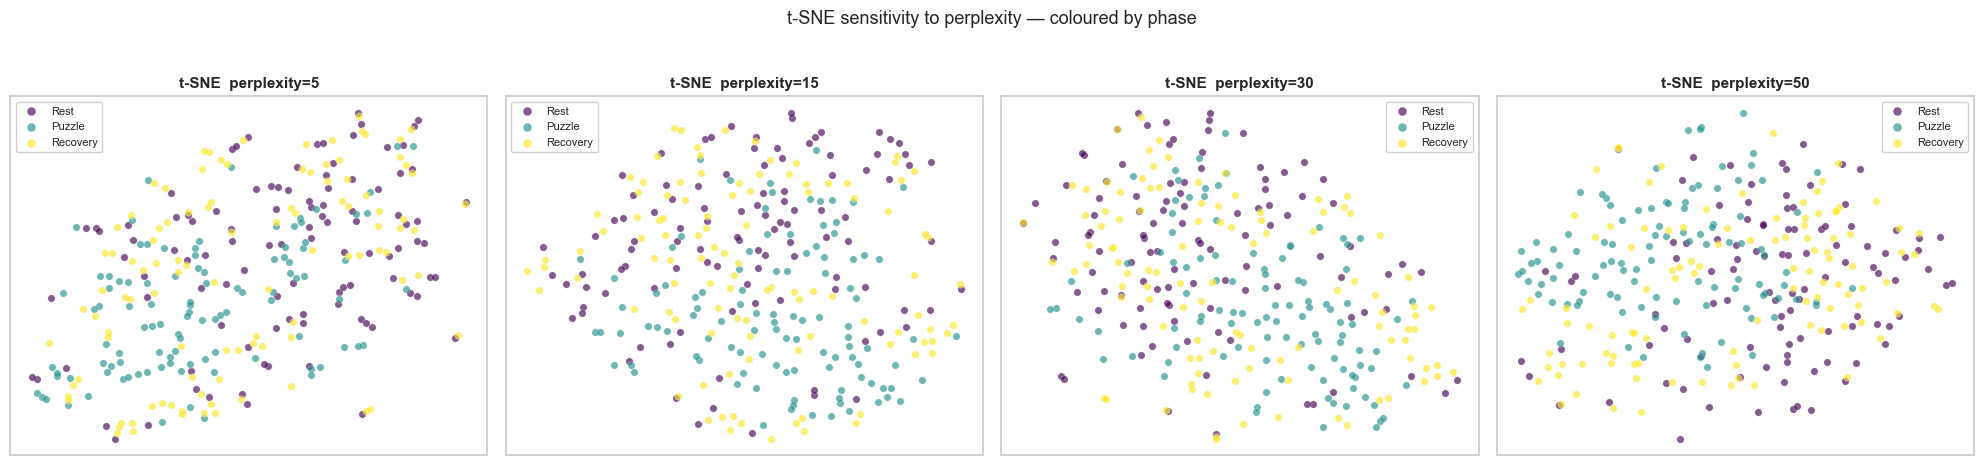

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, perp in zip(axes, PERPLEXITIES):
    plot_embedding_phase(tsne_embeddings[perp], ax, title=f't-SNE  perplexity={perp}')
plt.suptitle('t-SNE sensitivity to perplexity — coloured by phase', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tsne_perplexity_phase.png', dpi=200, bbox_inches='tight')
plt.show()

### 1.2 t-SNE embeddings coloured by subject

The same four embeddings, now coloured by subject ID. This is the critical diagnostic: if clusters align with subject colours rather than phase colours, the embedding is recovering *who* the person is, not *what* they were doing.

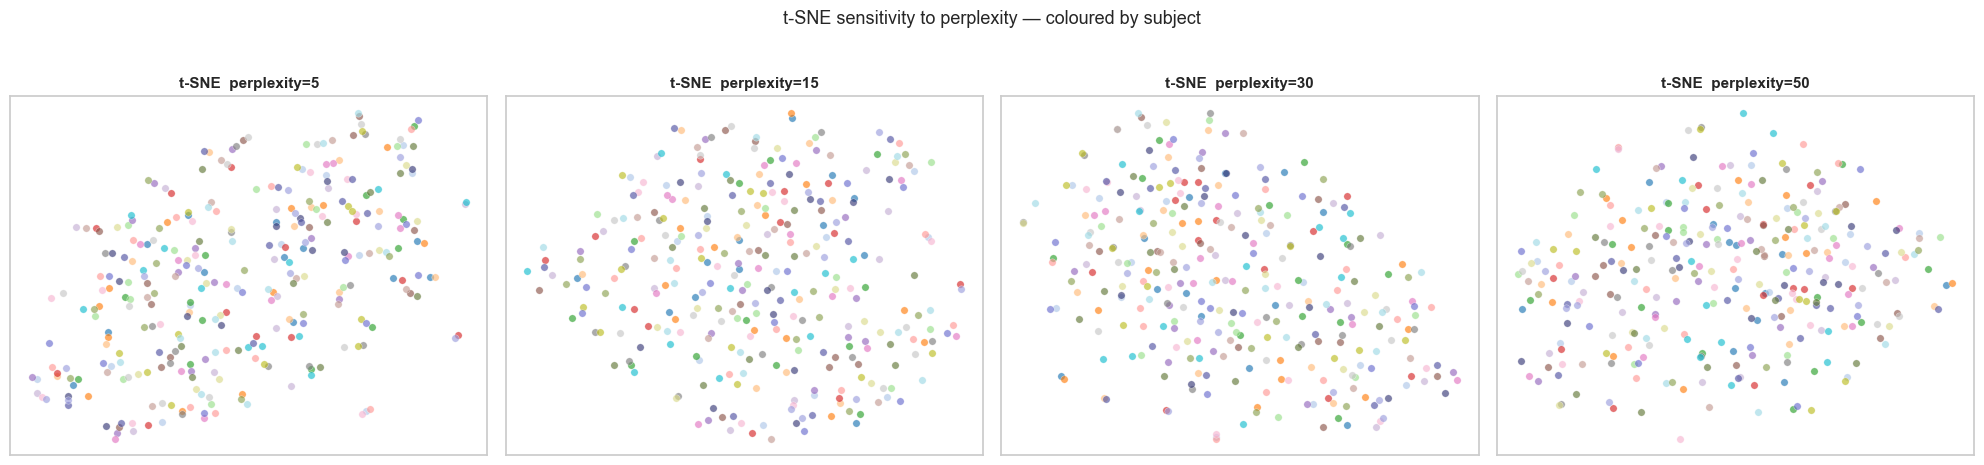

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, perp in zip(axes, PERPLEXITIES):
    plot_embedding_subject(tsne_embeddings[perp], ax, title=f't-SNE  perplexity={perp}')
plt.suptitle('t-SNE sensitivity to perplexity — coloured by subject', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tsne_perplexity_subject.png', dpi=200, bbox_inches='tight')
plt.show()

### 1.3 t-SNE interpretation

The phase-coloured plots show **no meaningful phase separation at any perplexity**. Rest, Puzzle, and Recovery points are thoroughly intermixed across all four panels. At perplexity = 5, the embedding fragments into many small clumps, but these do not correspond to phases — the three colours appear in roughly equal proportions within each clump. As perplexity increases (15 → 30 → 50), the layout smooths out into a single diffuse cloud with no visible phase boundaries.

The subject-coloured plots reveal what the small clumps at low perplexity actually represent: **residual subject identity**. At perplexity = 5, same-subject points (same colour) tend to sit near each other, forming mini-clusters of 2–4 points. This is expected — even after per-subject z-scoring, there is residual within-subject correlation across rounds that t-SNE's local neighbourhood search picks up. As perplexity increases to 30–50, these subject clusters dissolve and subjects become well intermixed, indicating that the per-subject z-scoring was largely effective at removing individual baselines.

The KL divergence decreases monotonically with perplexity (1.43 → 0.90), which is normal — higher perplexity means broader kernels and a smoother probability distribution that is easier to match.

**Bottom line:** t-SNE confirms Phase 2's finding. The phase signal in `X_subjz` is too weak for t-SNE to separate, regardless of perplexity. The only structure t-SNE finds is residual subject identity at low perplexity, and even that fades at higher perplexity values.

---
## 2. UMAP: sensitivity to `n_neighbors` and `min_dist`

### How UMAP works (brief)

UMAP constructs a weighted graph in high-dimensional space (connecting each point to its `n_neighbors` nearest neighbours) and then finds a low-dimensional layout that best preserves the topology of this graph. It differs from t-SNE in two important ways:

1. **Better global structure preservation.** t-SNE uses a fixed Student-t kernel in the low-dimensional space, which makes all inter-cluster distances roughly equal regardless of their true separation. UMAP uses a more flexible repulsive force, so clusters that are far apart in the original space tend to remain far apart in the embedding.
2. **Deterministic with a fixed seed.** Unlike t-SNE (which can give visually different layouts across runs even with the same parameters), UMAP with a fixed `random_state` is reproducible.

### The two key hyperparameters

- **`n_neighbors`** (analogous to perplexity): controls the balance between local and global structure. Small values (5–10) emphasise fine-grained local clusters; large values (30–50) give a more global, zoomed-out view.
- **`min_dist`**: controls how tightly the embedding packs points together. `min_dist=0.0` allows points to clump densely (good for identifying tight clusters); `min_dist=0.5` forces more spread (better for preserving continuous gradients).

### Why we vary both

We sweep a grid of `n_neighbors` × `min_dist` to test whether any visible phase separation is robust to these choices or only appears under specific settings.

In [7]:
N_NEIGHBORS_LIST = [5, 15, 30, 50]
MIN_DIST_LIST    = [0.0, 0.25, 0.5]

umap_embeddings = {}
for nn in N_NEIGHBORS_LIST:
    for md in MIN_DIST_LIST:
        reducer = umap.UMAP(
            n_neighbors=nn,
            min_dist=md,
            n_components=2,
            metric='euclidean',
            random_state=RNG_SEED,
        )
        umap_embeddings[(nn, md)] = reducer.fit_transform(X_subjz)
        print(f'  n_neighbors={nn:3d}, min_dist={md:.2f}  — done')

/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=  5, min_dist=0.00  — done


/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=  5, min_dist=0.25  — done
  n_neighbors=  5, min_dist=0.50  — done


/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

  n_neighbors= 50, min_dist=0.00  — done


/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors= 50, min_dist=0.25  — done


/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors= 50, min_dist=0.50  — done


### 2.1 UMAP grid — coloured by phase

Rows vary `min_dist` (packing tightness), columns vary `n_neighbors` (local vs. global focus). We are looking for configurations where phase colours cluster together.

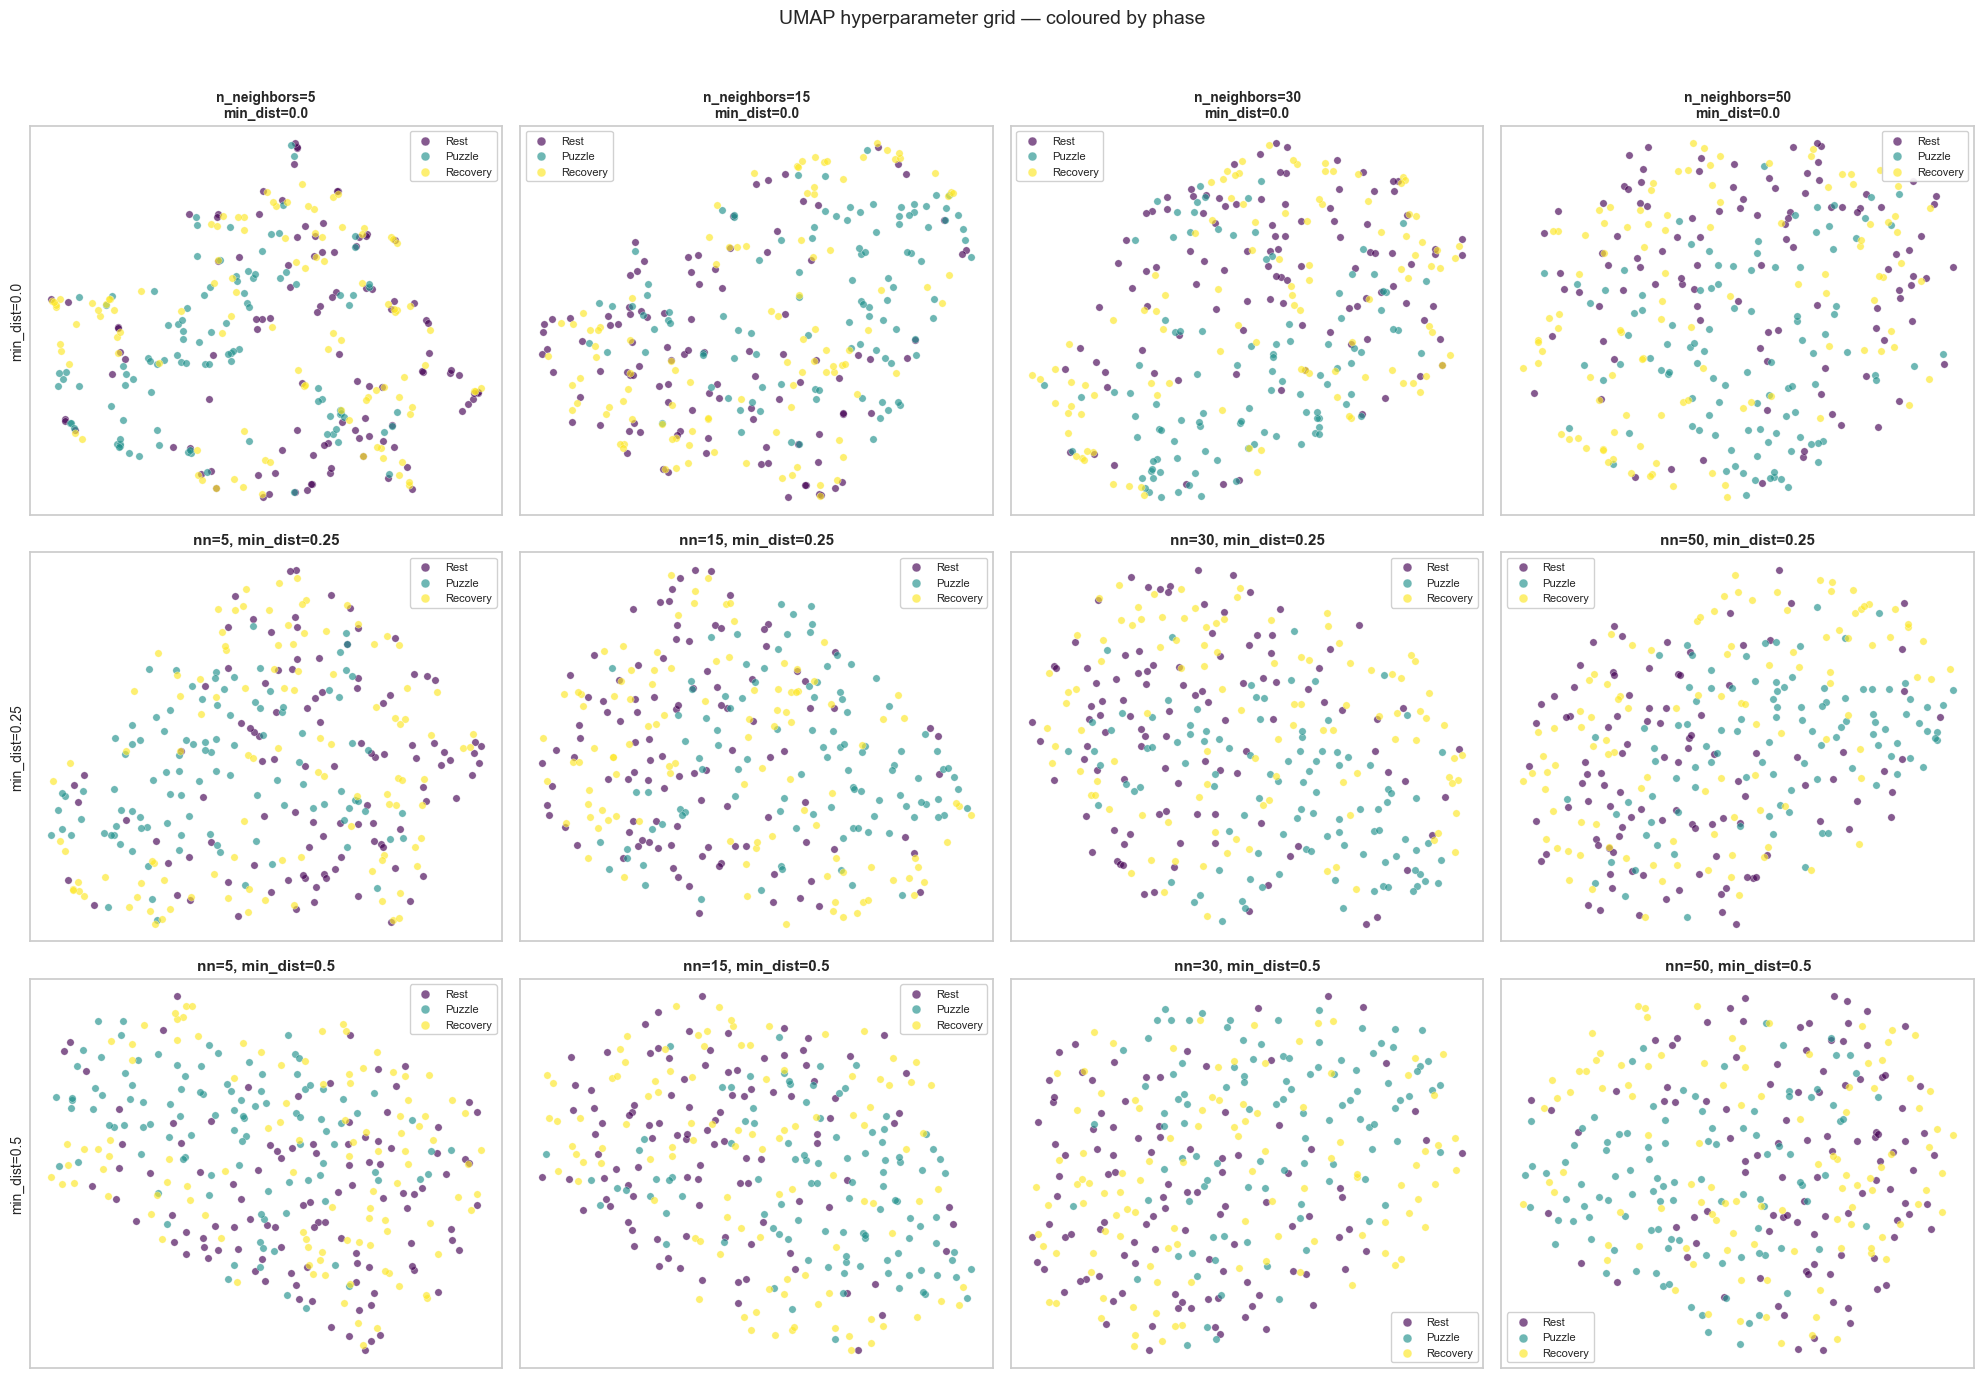

In [8]:
n_rows = len(MIN_DIST_LIST)
n_cols = len(N_NEIGHBORS_LIST)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
for i, md in enumerate(MIN_DIST_LIST):
    for j, nn in enumerate(N_NEIGHBORS_LIST):
        ax = axes[i, j]
        plot_embedding_phase(umap_embeddings[(nn, md)], ax,
                             title=f'nn={nn}, min_dist={md}')
        if i == 0:
            ax.set_title(f'n_neighbors={nn}\nmin_dist={md}', fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'min_dist={md}', fontsize=10)

plt.suptitle('UMAP hyperparameter grid — coloured by phase', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'umap_grid_phase.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.2 UMAP grid — coloured by subject

Same grid, coloured by subject. This tells us whether UMAP's clusters correspond to individuals.

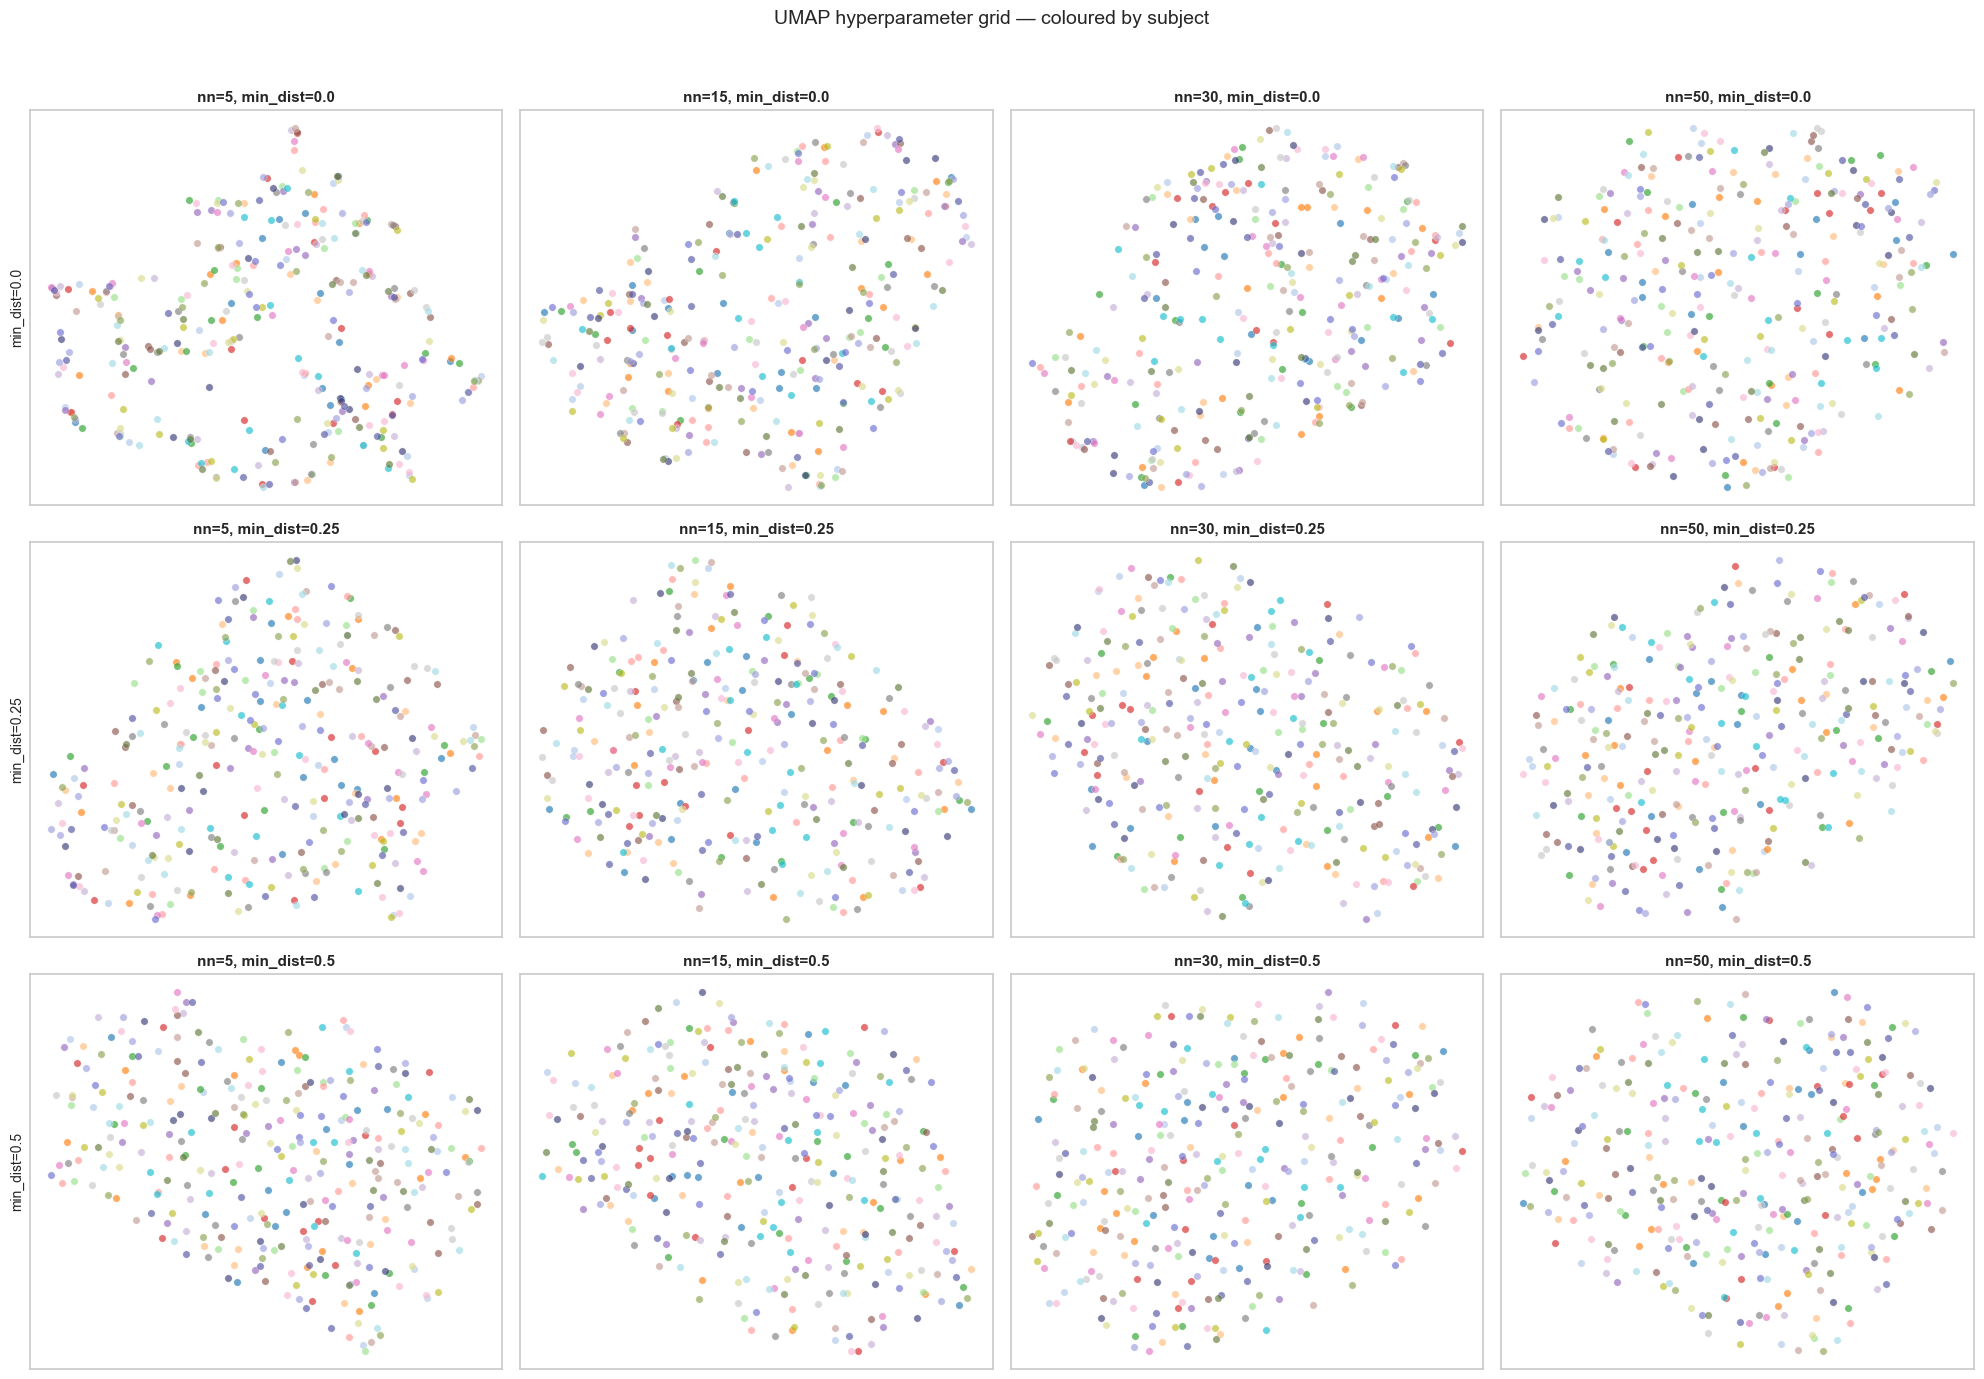

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
for i, md in enumerate(MIN_DIST_LIST):
    for j, nn in enumerate(N_NEIGHBORS_LIST):
        ax = axes[i, j]
        plot_embedding_subject(umap_embeddings[(nn, md)], ax,
                               title=f'nn={nn}, min_dist={md}')
        if j == 0:
            ax.set_ylabel(f'min_dist={md}', fontsize=10)

plt.suptitle('UMAP hyperparameter grid — coloured by subject', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'umap_grid_subject.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.3 UMAP interpretation

The phase-coloured grid shows a **subtle but consistent trend** that was absent in t-SNE: at higher `n_neighbors` (30, 50) with `min_dist = 0.0`, there is a soft spatial tendency for Recovery (yellow) points to concentrate toward one side of the embedding and Rest (purple) toward the other, with Puzzle (teal) distributed in between. This is most visible at `(nn=50, min_dist=0.0)`. However, the overlap between phases remains heavy — this is a statistical tendency, not a clean separation.

At low `n_neighbors` (5), UMAP behaves similarly to low-perplexity t-SNE: the embedding breaks into many small disconnected clumps. The subject-coloured grid confirms that at `nn = 5`, these clumps often correspond to same-subject groups (residual individual identity). As `n_neighbors` increases, subjects become increasingly intermixed.

The effect of `min_dist` is visible but secondary: `min_dist = 0.0` produces tighter, more clumped layouts that make any local grouping (by phase or subject) easier to see; `min_dist = 0.5` forces points apart and yields a more diffuse, uniform cloud where structure is harder to visually assess.

**Bottom line:** UMAP with high `n_neighbors` and low `min_dist` reveals a marginal phase-related gradient that t-SNE missed entirely. This is consistent with UMAP's known advantage in preserving global topology — the weak phase effect is more of a global trend than a local neighbourhood structure. Still, the separation is far too weak to be called "clustering"; it is at best a soft directional bias.

---
## 3. Head-to-head comparison: PCA vs. t-SNE vs. UMAP

### Why this comparison matters

Each method makes fundamentally different assumptions about what "structure" means:

| Method | Preserves | Loses | Interpretable axes? |
|--------|-----------|-------|---------------------|
| PCA | Global variance (linear) | Non-linear manifold curvature | Yes — loadings map back to features |
| t-SNE | Local neighbourhoods | Global distances (inter-cluster spacing is meaningless) | No — axes have no feature interpretation |
| UMAP | Local neighbourhoods + some global topology | Exact distances | No — axes have no feature interpretation |

Placing them side-by-side on the same data with the same colour coding lets us see whether non-linear methods reveal structure that PCA's linear lens misses — or whether all three agree that the phase signal is weak.

We pick one "representative" setting for each non-linear method. The choice of representative is guided by the hyperparameter sweeps above: we select the setting that showed the most stable, readable structure.

In [10]:
# --- Choose representative hyperparameter settings ---
# Adjust these after inspecting sections 1 and 2 above.
TSNE_REPR_PERP = 30            # perplexity that gave the most stable structure
UMAP_REPR_NN   = 15            # n_neighbors for the representative UMAP
UMAP_REPR_MD   = 0.25          # min_dist for the representative UMAP

emb_pca  = X_pca_2d
emb_tsne = tsne_embeddings[TSNE_REPR_PERP]
emb_umap = umap_embeddings[(UMAP_REPR_NN, UMAP_REPR_MD)]

### 3.1 Side-by-side: coloured by phase

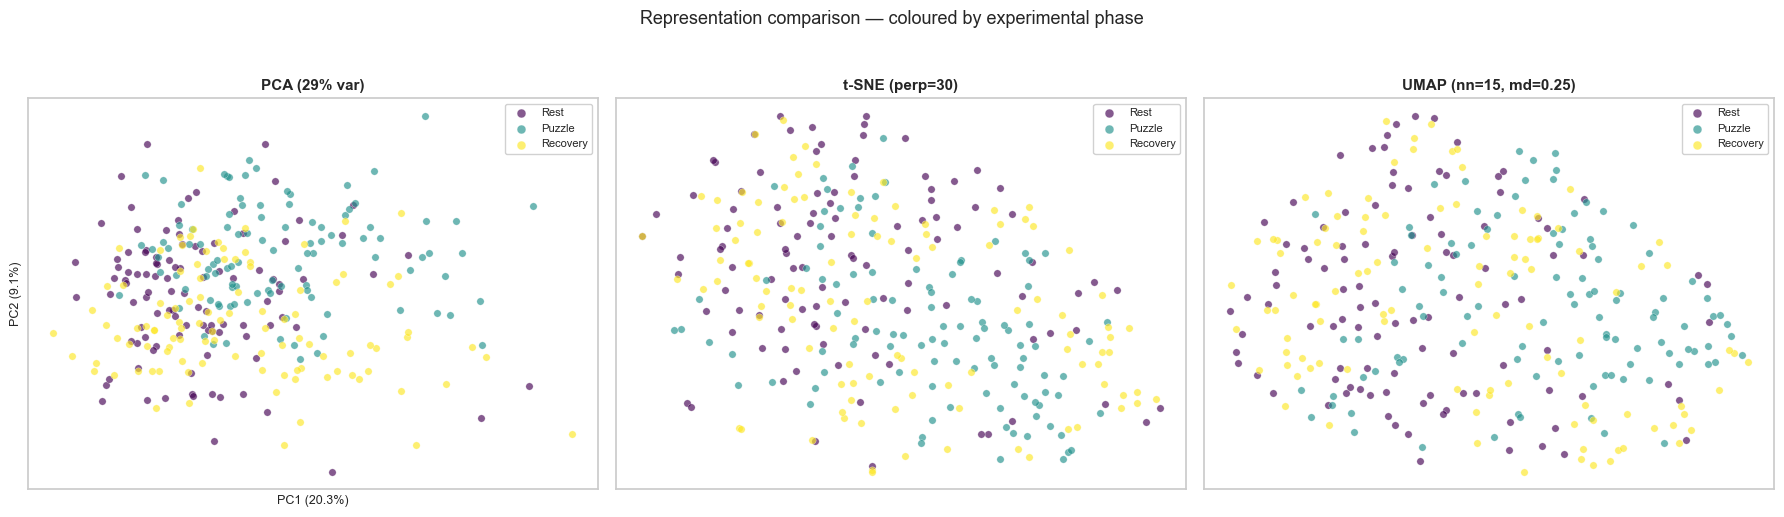

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_embedding_phase(emb_pca,  axes[0], title=f'PCA ({pca_var.sum():.0%} var)')
plot_embedding_phase(emb_tsne, axes[1], title=f't-SNE (perp={TSNE_REPR_PERP})')
plot_embedding_phase(emb_umap, axes[2], title=f'UMAP (nn={UMAP_REPR_NN}, md={UMAP_REPR_MD})')

# Add axis labels to PCA only (the only method where axes have meaning)
axes[0].set_xlabel(f'PC1 ({pca_var[0]:.1%})', fontsize=9)
axes[0].set_ylabel(f'PC2 ({pca_var[1]:.1%})', fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

plt.suptitle('Representation comparison — coloured by experimental phase', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_phase.png', dpi=200, bbox_inches='tight')
plt.show()

### 3.2 Side-by-side: coloured by subject

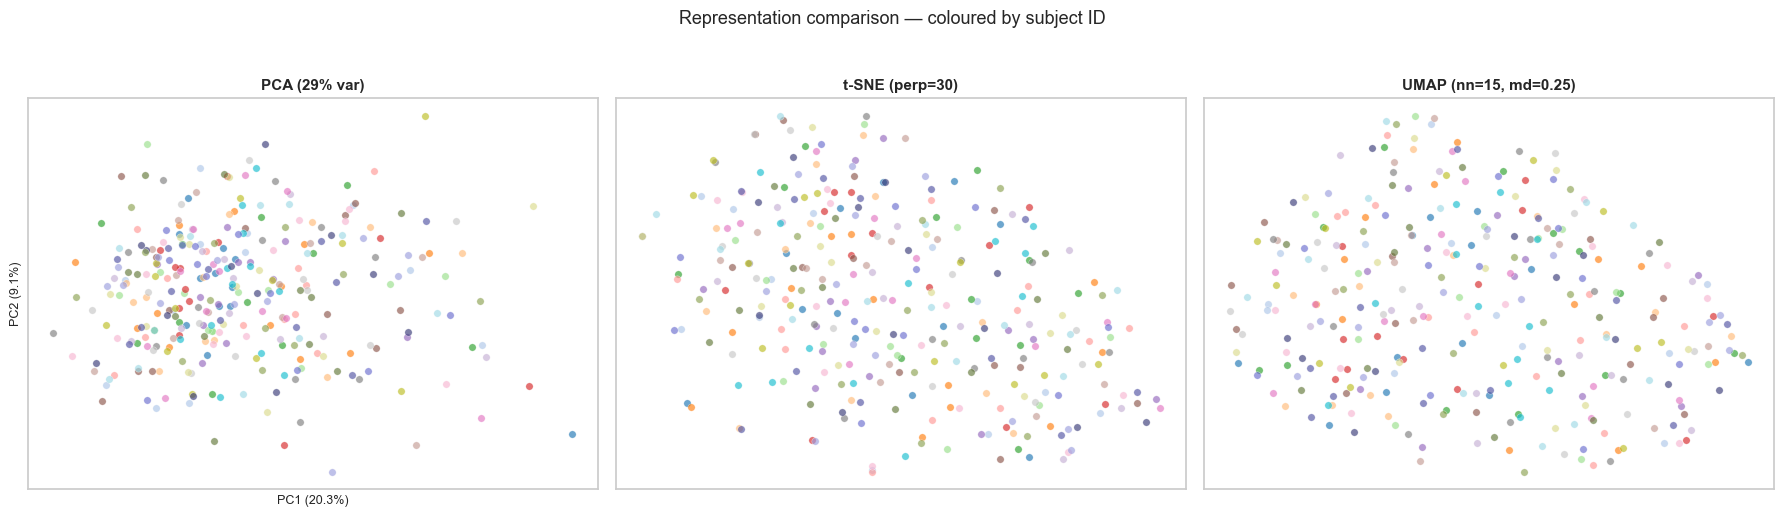

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_embedding_subject(emb_pca,  axes[0], title=f'PCA ({pca_var.sum():.0%} var)')
plot_embedding_subject(emb_tsne, axes[1], title=f't-SNE (perp={TSNE_REPR_PERP})')
plot_embedding_subject(emb_umap, axes[2], title=f'UMAP (nn={UMAP_REPR_NN}, md={UMAP_REPR_MD})')

axes[0].set_xlabel(f'PC1 ({pca_var[0]:.1%})', fontsize=9)
axes[0].set_ylabel(f'PC2 ({pca_var[1]:.1%})', fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

plt.suptitle('Representation comparison — coloured by subject ID', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_subject.png', dpi=200, bbox_inches='tight')
plt.show()

### 3.3 Comparison interpretation

Placed side by side, **all three methods tell a consistent story: phase separation in `X_subjz` is weak and diffuse**.

PCA shows a gentle gradient along PC1/PC2 where Rest and Recovery occupy slightly different regions of the variance space, but the overlap is heavy. t-SNE (perplexity = 30) shows an entirely intermixed cloud — phases are indistinguishable. UMAP (nn = 15, md = 0.25) falls between the two: there is a faint directional tendency similar to PCA's gradient but no discrete clusters.

Crucially, PCA captures ~29% of variance in just two components and already exhibits the clearest (though still weak) hint of phase organisation. The fact that t-SNE and UMAP do not improve on this suggests that **the phase signal, to the extent it exists, is approximately linear** — it lives along a small number of directions in feature space (the EDA/HR/temperature axes identified by Phase 2) rather than on a curved manifold. Non-linear methods had no hidden non-linear structure to exploit.

The subject-coloured comparison confirms that per-subject z-scoring successfully removed the dominant source of variance (individual baselines) across all three methods. Subjects are well intermixed in every embedding, which is the intended effect of the normalisation.

---
## 4. Bonus: non-linear embeddings on delta features

### Motivation

Phase 1 engineered a **within-round baseline delta** matrix: for each row, the phase-1 (rest) values from the same subject and round are subtracted. This removes subject baselines *and* round-to-round drift in a single operation, leaving only the within-round response to the experimental manipulation.

The delta features were not used in Phase 2's PCA. Running t-SNE and UMAP on them tests a different hypothesis: **if we give the embedding only the *change* from rest, does phase structure become visible?**

Note that by construction, all phase-1 rows have `delta = 0` (they are their own baseline). So in the delta embedding, all rest segments should collapse to a single point — any spread among them is noise.

In [13]:
from sklearn.preprocessing import StandardScaler

delta_raw = bundle['delta']
delta_vals = delta_raw.values if hasattr(delta_raw, 'values') else delta_raw

# z-score the delta features so they enter on the same scale
delta_scaled = StandardScaler().fit_transform(delta_vals)

print(f'Delta matrix: {delta_scaled.shape}')
print(f'Phase-1 rows all zero? {np.allclose(delta_vals[phase_labels == "phase1"], 0.0)}')

Delta matrix: (312, 51)
Phase-1 rows all zero? True


In [14]:
# t-SNE on delta (use the same representative perplexity)
tsne_delta = TSNE(
    n_components=2, perplexity=TSNE_REPR_PERP,
    max_iter=2000, learning_rate='auto', init='pca', random_state=RNG_SEED
).fit_transform(delta_scaled)

# UMAP on delta (use the same representative settings)
umap_delta = umap.UMAP(
    n_neighbors=UMAP_REPR_NN, min_dist=UMAP_REPR_MD,
    n_components=2, random_state=RNG_SEED
).fit_transform(delta_scaled)

# PCA on delta for comparison
pca_delta = PCA(n_components=2, random_state=RNG_SEED)
pca_delta_2d = pca_delta.fit_transform(delta_scaled)

print('Delta embeddings computed.')

/Users/elena.schneider/cda-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Delta embeddings computed.


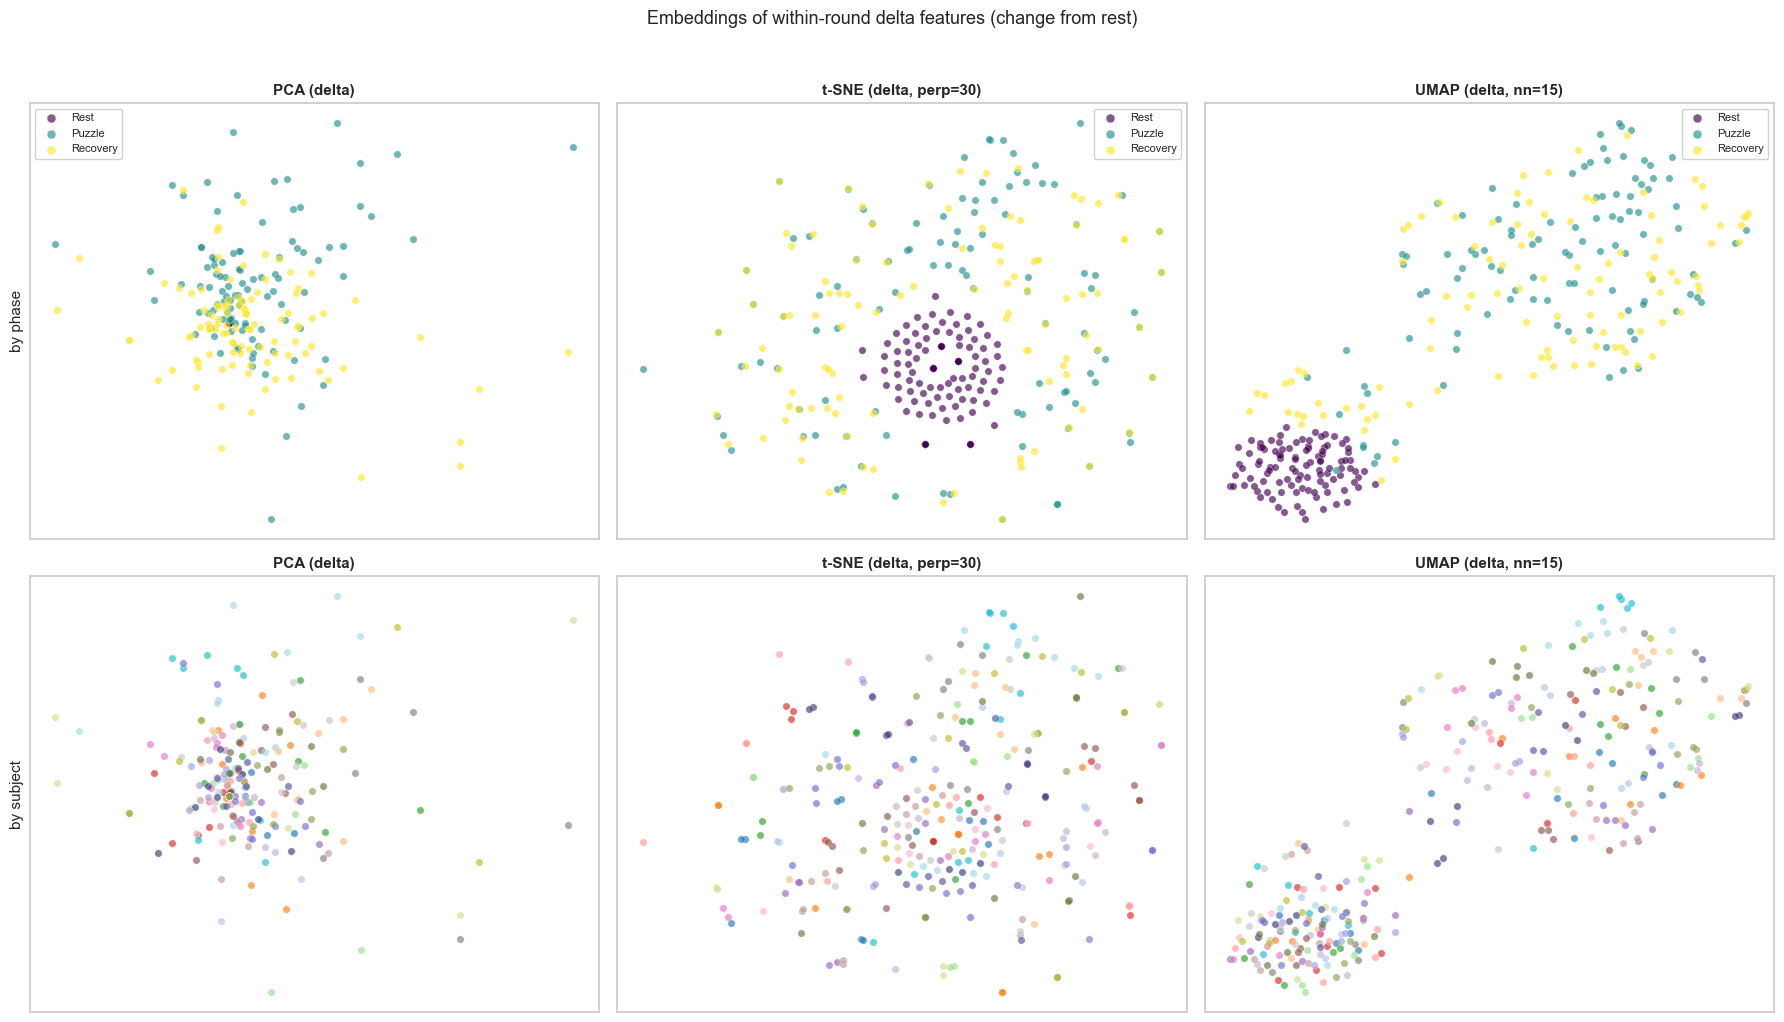

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: coloured by phase
plot_embedding_phase(pca_delta_2d, axes[0, 0], title='PCA (delta)')
plot_embedding_phase(tsne_delta,   axes[0, 1], title=f't-SNE (delta, perp={TSNE_REPR_PERP})')
plot_embedding_phase(umap_delta,   axes[0, 2], title=f'UMAP (delta, nn={UMAP_REPR_NN})')

# Bottom row: coloured by subject
plot_embedding_subject(pca_delta_2d, axes[1, 0], title='PCA (delta)')
plot_embedding_subject(tsne_delta,   axes[1, 1], title=f't-SNE (delta, perp={TSNE_REPR_PERP})')
plot_embedding_subject(umap_delta,   axes[1, 2], title=f'UMAP (delta, nn={UMAP_REPR_NN})')

axes[0, 0].set_ylabel('by phase', fontsize=11)
axes[1, 0].set_ylabel('by subject', fontsize=11)

plt.suptitle('Embeddings of within-round delta features (change from rest)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'delta_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()

### 4.1 Delta embedding interpretation

The delta features produce the **strongest phase structure of any representation tested in this notebook**, and the improvement is dramatic.

**Rest collapses as expected.** In all three methods, the phase-1 (Rest) points form a tight, dense cluster — this is by construction, since their delta values are identically zero. This cluster serves as a visual anchor: everything else represents physiological *change* from the resting baseline.

**Phase separation emerges.** In PCA, the Puzzle (teal) and Recovery (yellow) points fan out from the rest cluster into distinct directions, suggesting that the stress response and recovery response have different signatures in delta space. In t-SNE, the Rest cluster is extremely compact and well separated from the Puzzle and Recovery points, which spread out around it with partial separation from each other. UMAP shows a similar pattern: Rest forms a tight island on one side, with Puzzle and Recovery distributed further away, partially intermixed but occupying somewhat different regions.

**Subject identity is suppressed.** The bottom row (coloured by subject) shows that the delta subtraction has largely eliminated per-subject clustering. In PCA, the Rest cluster contains all 26 subjects overlapping at the origin, and the active-state points show only mild residual subject grouping. In t-SNE and UMAP, subjects are well intermixed among the non-rest points. This is the benefit of within-round baseline subtraction: it removes not just the subject mean (as `X_subjz` does) but also round-to-round drift within each subject.

**Key insight:** the fact that delta features produce better phase separation than `X_subjz` — especially in non-linear embeddings — suggests that the physiological response to the experimental manipulation is best captured as *change from a within-round baseline* rather than as *deviation from a subject mean*. This is a useful finding for Phase 4 and for the report: it highlights that feature engineering choices (how baselines are removed) matter more for this dataset than the choice of linear vs. non-linear embedding.

---
## 5. Methodological discussion

### 5.1 What each method brings to the table

**PCA** is the only method here that gives *interpretable axes*. Each principal component is a linear combination of the original 51 features, so the loadings tell us "PC1 is driven by EDA, PC2 by HR, PC3 by temperature" (as Phase 2 showed). This interpretability is critical for the report — it connects the representation to physiology. The cost is that PCA can only find flat subspaces.

**t-SNE** is a pure visualisation tool. It excels at making local clusters visible in 2D, which is why it is so popular for exploring high-dimensional data. However, its axes are arbitrary (rotating or scaling the plot changes nothing), distances between clusters are not meaningful, and results depend on perplexity and random seed. It should not be used for downstream modelling (e.g., clustering the t-SNE coordinates is circular — the embedding already imposed a neighbourhood structure).

**UMAP** shares t-SNE's strengths in local-structure preservation but with two advantages: it better preserves global topology (so inter-cluster distances carry *some* meaning), and it has a well-defined mathematical framework (fuzzy simplicial sets) that makes it less of a black box. Like t-SNE, its axes are uninterpretable.

### 5.2 Limitations specific to this dataset

- **Small n, many features.** 312 samples in 51 dimensions is not particularly high-dimensional, and the sample size is modest. Non-linear methods can overfit noise in this regime — a concern that PCA, being constrained to linear projections, is less susceptible to.
- **Repeated measures.** Each subject contributes 12 rows that are not independent. t-SNE and UMAP treat every row as an independent point, which means they will naturally group same-subject rows together. This is a feature or a bug depending on the research question.
- **No test set.** All embeddings are fit on the same 312 rows used for visualisation. There is no out-of-sample evaluation of the representations in this phase; that is deferred to Phase 4.

### 5.3 Overall assessment

Non-linear methods (t-SNE, UMAP) **did not reveal phase structure that PCA missed** when applied to the subject-normalised features (`X_subjz`). All three methods agree that the phase signal on this feature matrix is weak and diffuse. At low neighbourhood sizes (perplexity 5, n_neighbors 5), both t-SNE and UMAP recover residual subject-identity clusters rather than phase clusters — the non-linear flexibility is exploited to capture individual noise, not experimental signal. At higher neighbourhood sizes, phases are thoroughly intermixed.

The one exception is the **within-round delta features**, where all three methods — and especially t-SNE and UMAP — show clear Rest vs. active-state separation and partial Puzzle vs. Recovery separation. This suggests that the phase effect exists but is masked by subject-level and round-level variability that `X_subjz` does not fully remove; the more surgical delta subtraction is needed to expose it.

**Recommended representations for Phase 4:**
1. PCA on `X_subjz` (the interpretable linear baseline)
2. UMAP on `X_subjz` at `(nn=30, min_dist=0.0)` (the non-linear method with the most visible phase gradient)
3. All three methods on delta features (the strongest phase separation found)

Phase 4 should quantify separation using ARI, silhouette, and a classification proxy on all of these, and should explicitly test whether the improvement from delta features is statistically robust or just visually suggestive.

---
## 6. Persist embeddings for Phase 4

We save all embeddings (PCA, t-SNE at all perplexities, UMAP at all settings, plus delta variants) in a single bundle so Phase 4 can load them without re-running any computation.

In [16]:
phase3_bundle = {
    # --- identifiers (for alignment) ---
    'phase_labels': phase_labels,
    'subject_ids':  subject_ids,

    # --- PCA baseline (recomputed on X_subjz) ---
    'pca_2d':  X_pca_2d,
    'pca_var': pca_var,

    # --- t-SNE embeddings ---
    'tsne_embeddings': tsne_embeddings,       # dict: perplexity -> (312, 2)
    'tsne_repr_perp':  TSNE_REPR_PERP,

    # --- UMAP embeddings ---
    'umap_embeddings': umap_embeddings,       # dict: (nn, md) -> (312, 2)
    'umap_repr_nn':    UMAP_REPR_NN,
    'umap_repr_md':    UMAP_REPR_MD,

    # --- Delta-feature embeddings ---
    'pca_delta_2d':  pca_delta_2d,
    'tsne_delta':    tsne_delta,
    'umap_delta':    umap_delta,
}

out_path = ART_DIR / 'case2_phase3_embeddings.pkl'
joblib.dump(phase3_bundle, out_path)
print(f'Saved → {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')

Saved → artifacts/case2_phase3/case2_phase3_embeddings.pkl  (58.7 KB)


### Key findings

1. **Non-linear methods do not improve phase separation on `X_subjz`.** t-SNE shows no phase grouping at any perplexity; UMAP shows a faint directional tendency at high `n_neighbors` but nothing that qualifies as clustering. PCA's linear projection captures the phase signal at least as well as — arguably better than — either non-linear method.

2. **At low neighbourhood sizes, non-linear methods recover residual subject identity rather than phase structure.** This is a known risk with repeated-measures data: each subject contributes 12 non-independent rows, and local methods will group them.

3. **Delta features are the strongest representation for phase separation.** When the within-round resting baseline is subtracted, all three methods clearly separate Rest from the active conditions, and partially separate Puzzle from Recovery. The improvement over `X_subjz` is substantial and consistent across methods.

4. **The phase signal appears to be approximately linear.** Since PCA performs comparably to t-SNE/UMAP on `X_subjz`, there is no evidence of non-linear manifold structure in the phase effect. The main bottleneck is not linear vs. non-linear methods, but how effectively subject/round baselines are removed.
